# Customer Behaviour Analysis

# Import Libraries

In [ ]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# File handling
import os
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

# Visualization settings
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

# Load Dataset

In [26]:
# Dataset path
file_path = r"C:\Users\amans\Downloads\E-commerce Customer Behavior - Sheet1.csv"

# Load CSV
df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

Dataset loaded successfully!
Dataset Shape: (350, 11)


In [27]:
# Display first 10 rows
df.head(10)

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
5,106,Female,37,Houston,Bronze,440.80,8,3.1,False,22,Neutral
6,107,Female,31,New York,Gold,1150.60,15,4.5,True,28,Satisfied
7,108,Male,35,Los Angeles,Silver,800.90,12,4.2,False,14,Neutral
8,109,Female,41,Chicago,Bronze,495.25,10,3.6,True,40,Unsatisfied
9,110,Male,28,San Francisco,Gold,1520.10,21,4.8,False,9,Satisfied


In [28]:
print("Dataset Information")
print("=" * 60)

print("\nNumber of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Information

Number of Rows: 350
Number of Columns: 11


In [29]:
print("\nColumn Names:")
print(df.columns.tolist())


Column Names:
['Customer ID', 'Gender', 'Age', 'City', 'Membership Type', 'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied', 'Days Since Last Purchase', 'Satisfaction Level']


In [30]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level           object
dtype: object


# Statistical Summary

In [31]:
# Statistical summary
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Customer ID,350.0,NaN,NaN,NaN,275.5,101.180532,101.0,188.25,275.5,362.75,450.0
Gender,350,2,Female,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,350.0,NaN,NaN,NaN,33.597143,4.870882,26.0,30.0,32.5,37.0,43.0
City,350,6,New York,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Membership Type,350,3,Gold,117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Spend,350.0,NaN,NaN,NaN,845.381714,362.058695,410.8,502.0,775.2,1160.6,1520.1
Items Purchased,350.0,NaN,NaN,NaN,12.6,4.155984,7.0,9.0,12.0,15.0,21.0
Average Rating,350.0,NaN,NaN,NaN,4.019143,0.580539,3.0,3.5,4.1,4.5,4.9
Discount Applied,350,2,True,175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Days Since Last Purchase,350.0,NaN,NaN,NaN,26.588571,13.440813,9.0,15.0,23.0,38.0,63.0


# Missing Value Analysis

In [32]:
# Missing values
missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percentage
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

missing_df

,Missing Values,Missing Percentage
Satisfaction Level,2,0.571429
Customer ID,0,0.000000
Gender,0,0.000000
Age,0,0.000000
City,0,0.000000
Membership Type,0,0.000000
Total Spend,0,0.000000
Items Purchased,0,0.000000
Average Rating,0,0.000000
Discount Applied,0,0.000000


In [33]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


In [34]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicates removed successfully!")
print("New dataset shape:", df.shape)

Duplicates removed successfully!
New dataset shape: (350, 11)


# Standardize Column Names

In [35]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['customer_id', 'gender', 'age', 'city', 'membership_type', 'total_spend', 'items_purchased', 'average_rating', 'discount_applied', 'days_since_last_purchase', 'satisfaction_level']


# Check Unique Values

In [36]:
# Display unique values for each column
for column in df.columns:
    print("\n" + "=" * 60)
    print("Column:", column)
    print("Number of unique values:", df[column].nunique())
    
    if df[column].nunique() <= 20:
        print("Unique values:")
        print(df[column].unique())


Column: customer_id
Number of unique values: 350

Column: gender
Number of unique values: 2
Unique values:
['Female' 'Male']

Column: age
Number of unique values: 16
Unique values:
[29 34 43 30 27 37 31 35 41 28 32 36 33 42 26 38]

Column: city
Number of unique values: 6
Unique values:
['New York' 'Los Angeles' 'Chicago' 'San Francisco' 'Miami' 'Houston']

Column: membership_type
Number of unique values: 3
Unique values:
['Gold' 'Silver' 'Bronze']

Column: total_spend
Number of unique values: 76

Column: items_purchased
Number of unique values: 15
Unique values:
[14 11  9 19 13  8 15 12 10 21  7 16 18 20 17]

Column: average_rating
Number of unique values: 20
Unique values:
[4.6 4.1 3.4 4.7 4.  3.1 4.5 4.2 3.6 4.8 3.8 3.2 4.3 4.4 3.5 4.9 3.7 3.
 3.3 3.9]

Column: discount_applied
Number of unique values: 2
Unique values:
[ True False]

Column: days_since_last_purchase
Number of unique values: 54

Column: satisfaction_level
Number of unique values: 3
Unique values:
['Satisfied' 'Neutra

In [37]:
# Identify numeric and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numeric Columns:")
print(list(numeric_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numeric Columns:
['customer_id', 'age', 'total_spend', 'items_purchased', 'average_rating', 'days_since_last_purchase']

Categorical Columns:
['gender', 'city', 'membership_type', 'satisfaction_level']


# Missing Value Treatment

In [38]:
# Fill numeric missing values using median
for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Fill categorical missing values using mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        mode_value = df[column].mode()
        
        if len(mode_value) > 0:
            df[column] = df[column].fillna(mode_value[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [39]:
print("Remaining Missing Values:")
print(df.isnull().sum())

print("\nRemaining Duplicate Records:")
print(df.duplicated().sum())

Remaining Missing Values:
customer_id                 0
gender                      0
age                         0
city                        0
membership_type             0
total_spend                 0
items_purchased             0
average_rating              0
discount_applied            0
days_since_last_purchase    0
satisfaction_level          0
dtype: int64

Remaining Duplicate Records:
0


# Outlier Detection

In [40]:
# IQR-based outlier detection
outlier_summary = {}

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    outlier_summary[column] = len(outliers)

outlier_df = pd.DataFrame(
    list(outlier_summary.items()),
    columns=["Column", "Outlier_Count"]
)

outlier_df

,Column,Outlier_Count
0,customer_id,0
1,age,0
2,total_spend,0
3,items_purchased,0
4,average_rating,0
5,days_since_last_purchase,0


# Exploratory Data Analysis

In [41]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print("Total Customers/Records:", len(df))
print("Total Features:", len(df.columns))

print("\nNumeric Features:")
print(list(numeric_columns))

print("\nCategorical Features:")
print(list(categorical_columns))

DATASET OVERVIEW
Total Customers/Records: 350
Total Features: 11

Numeric Features:
['customer_id', 'age', 'total_spend', 'items_purchased', 'average_rating', 'days_since_last_purchase']

Categorical Features:
['gender', 'city', 'membership_type', 'satisfaction_level']


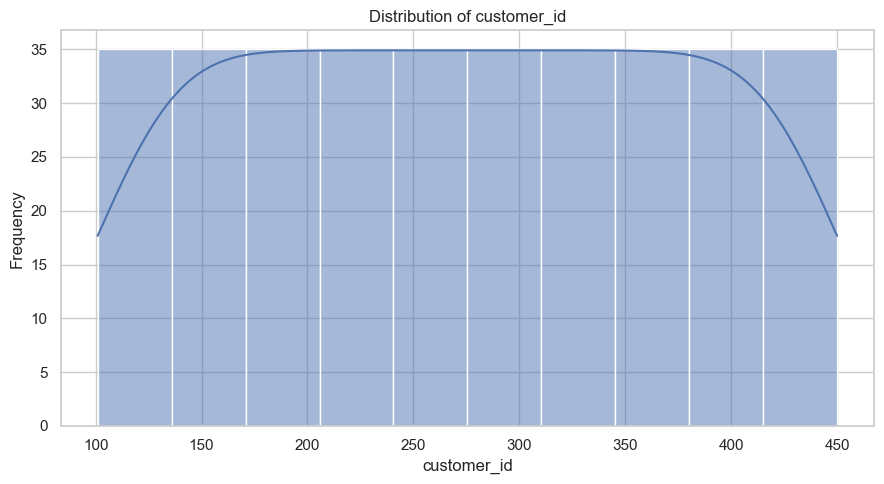

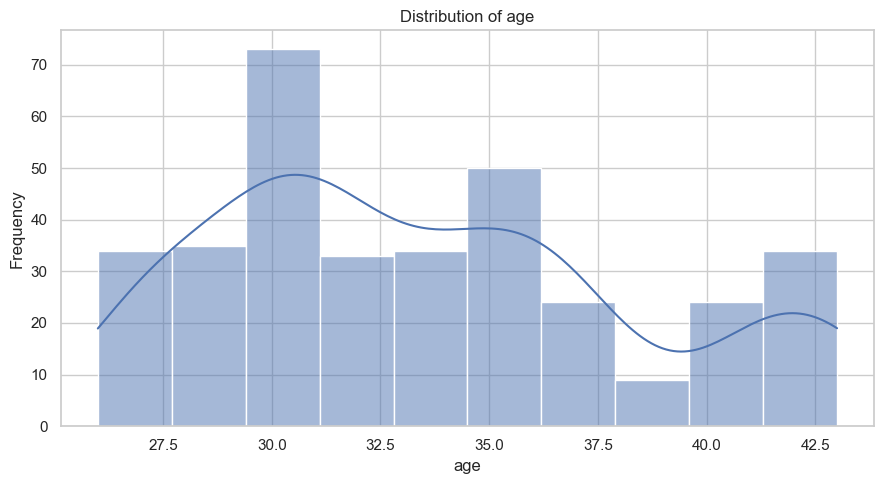

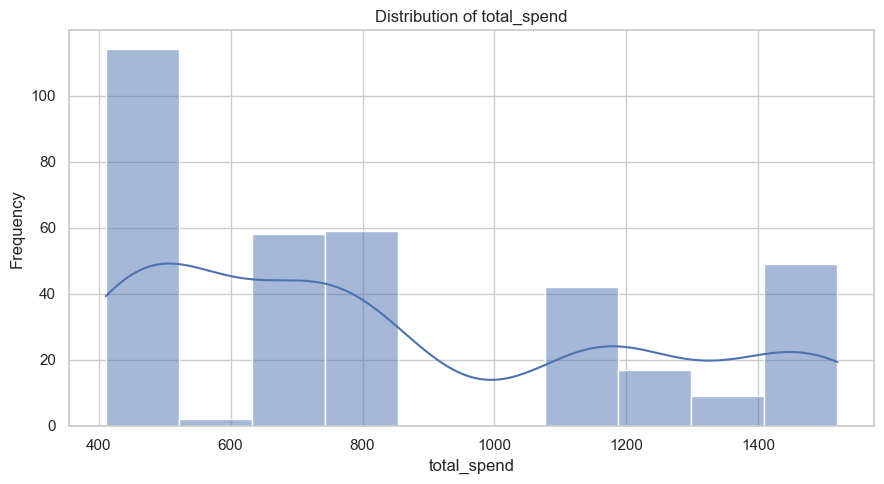

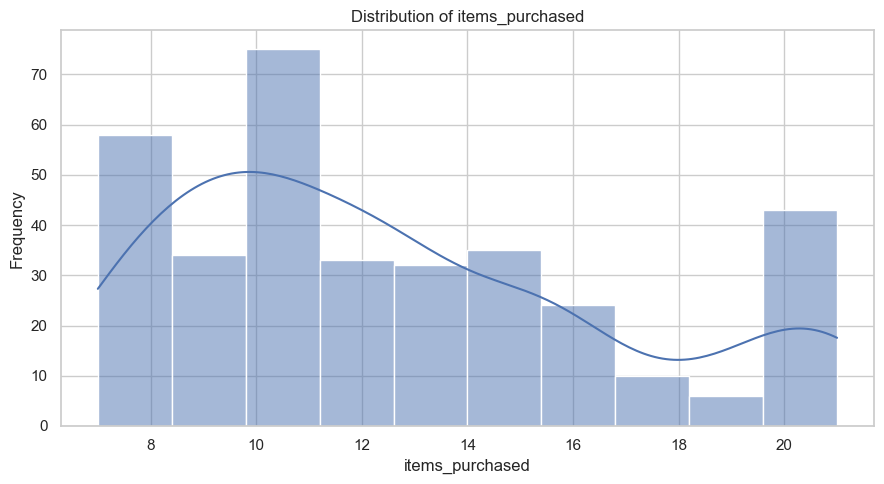

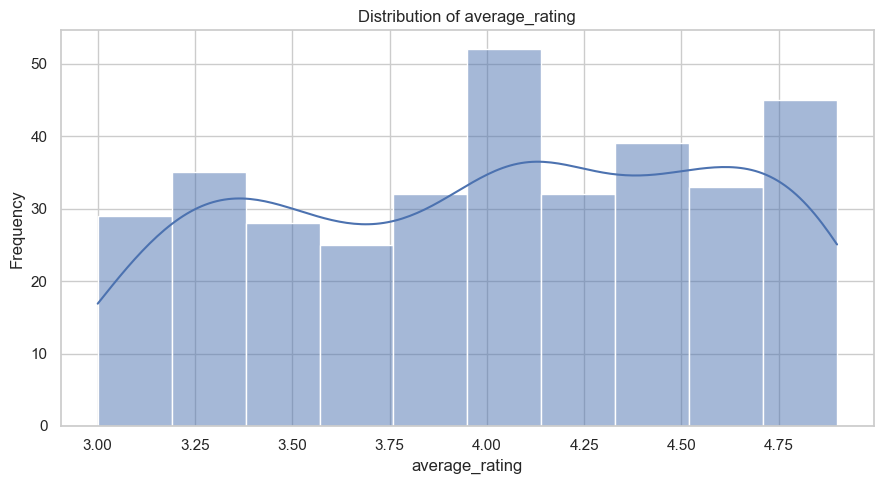

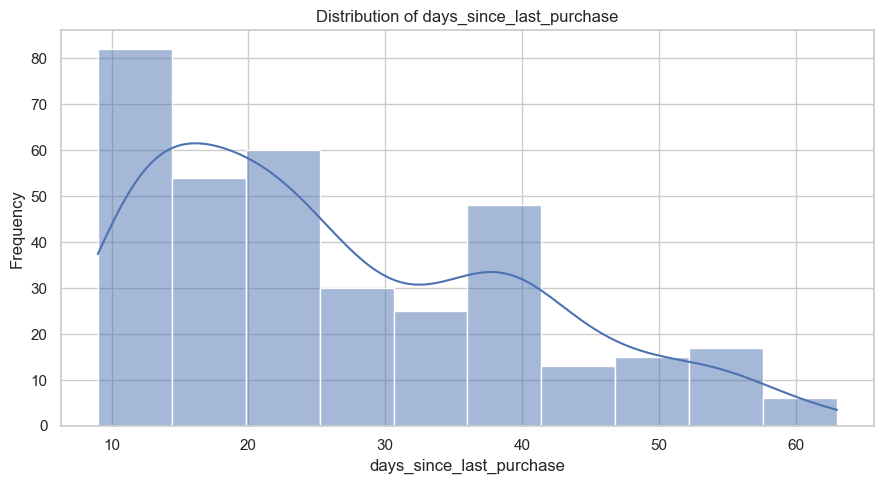

In [42]:
# Histograms for numerical columns
for column in numeric_columns:
    
    plt.figure(figsize=(9, 5))
    
    sns.histplot(
        data=df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

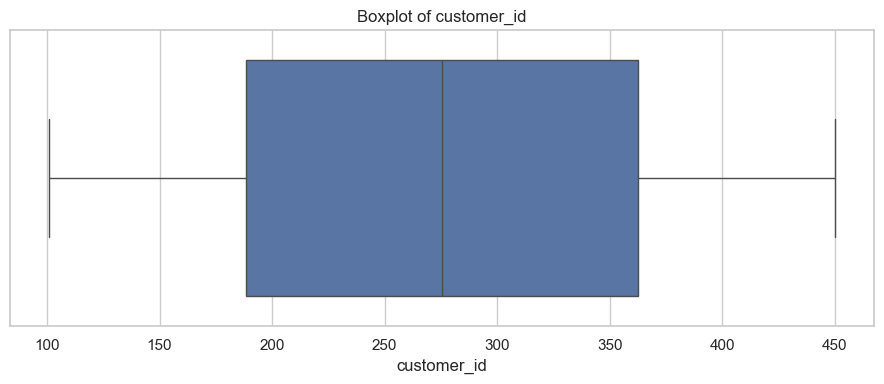

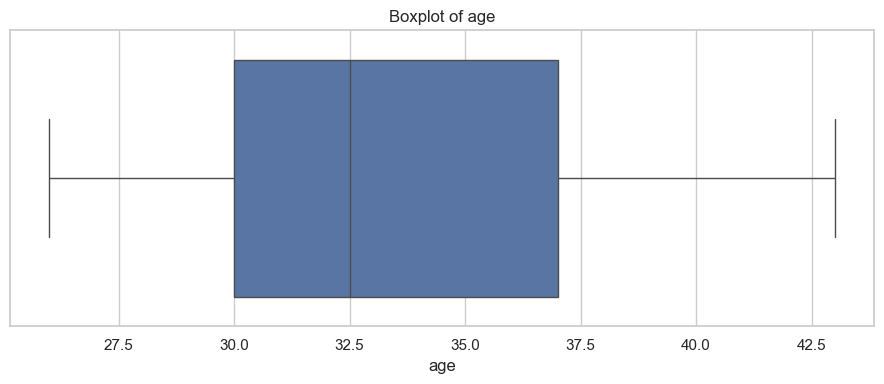

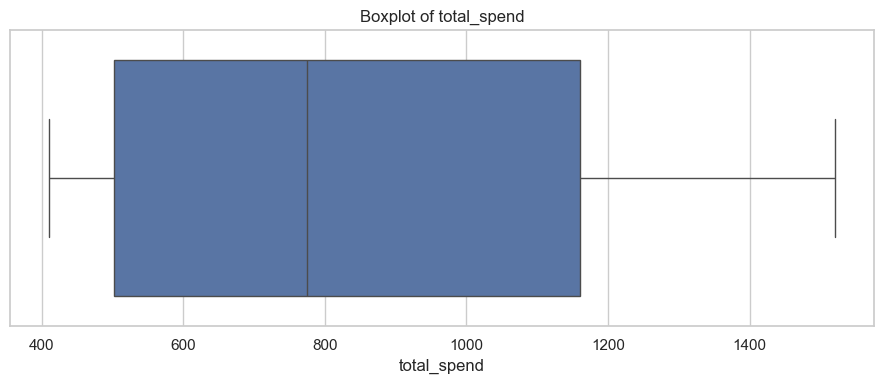

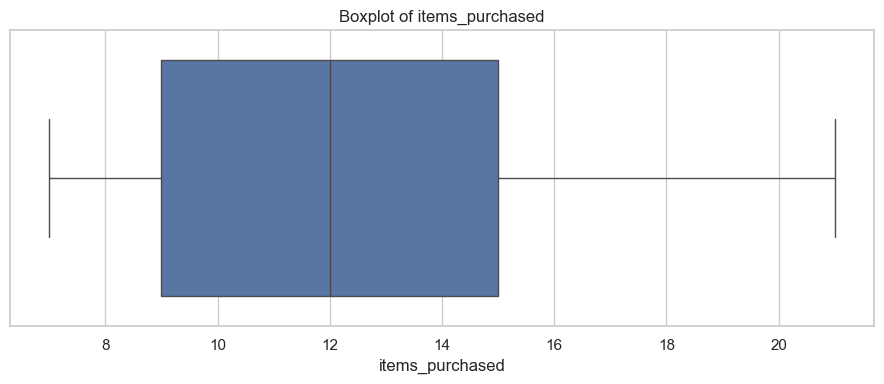

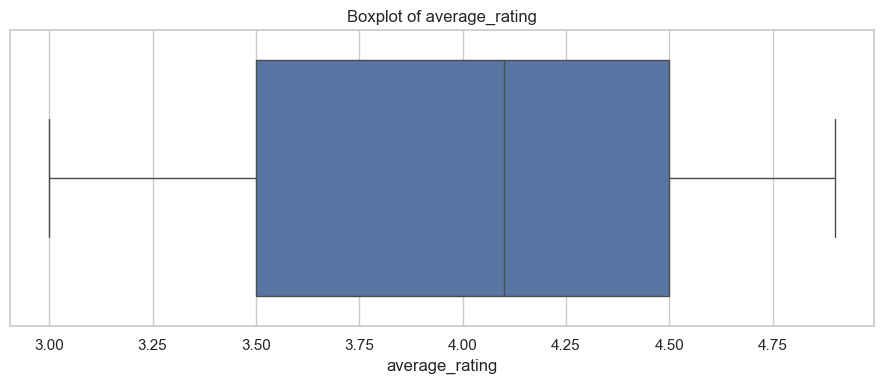

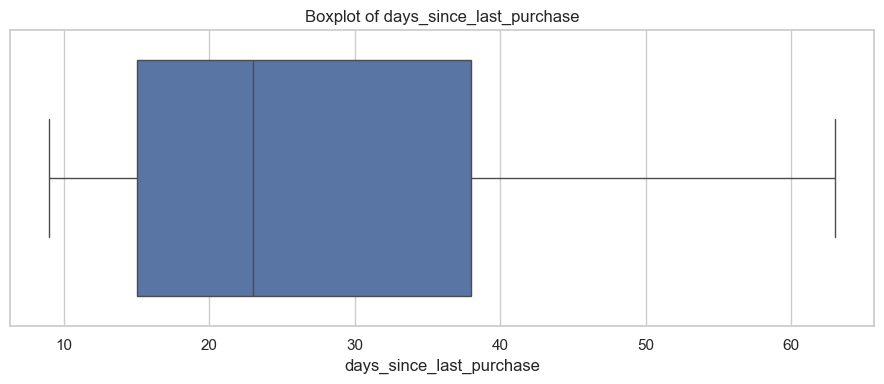

In [43]:
# Boxplots for numerical variables
for column in numeric_columns:
    
    plt.figure(figsize=(9, 4))
    
    sns.boxplot(
        x=df[column]
    )
    
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    
    plt.tight_layout()
    plt.show()

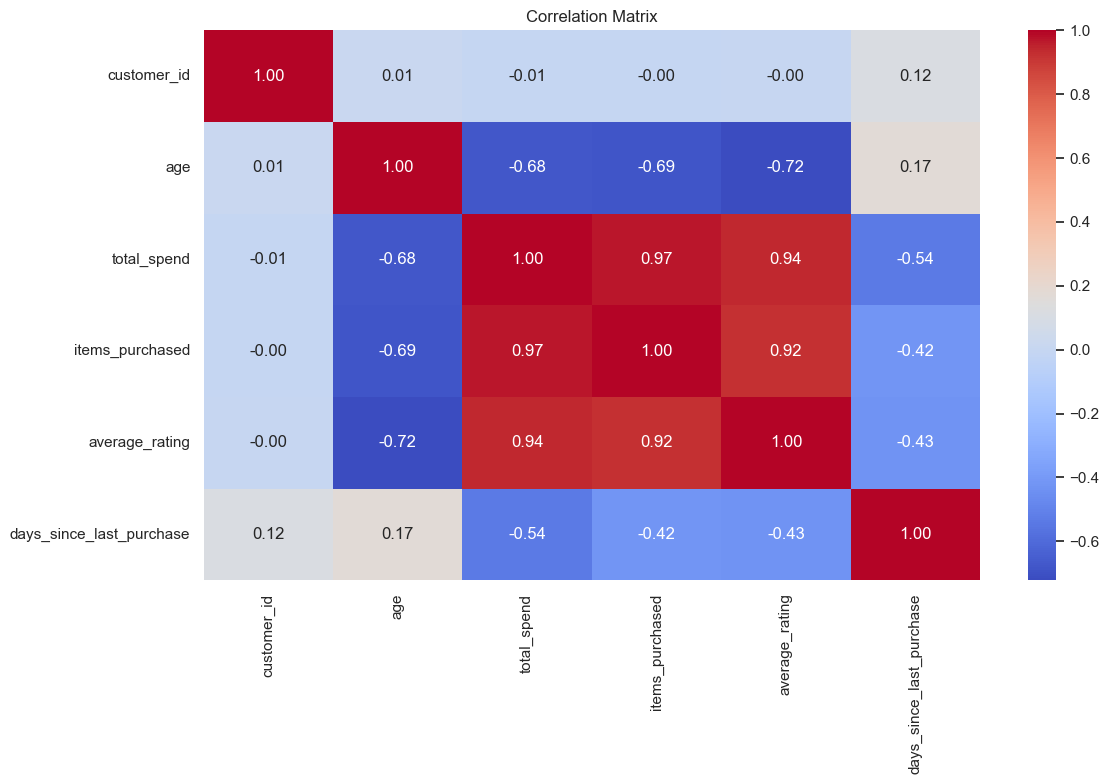

In [44]:
# Correlation matrix
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [45]:
for column in categorical_columns:
    
    print("\n" + "=" * 70)
    print("Analysis:", column)
    print("=" * 70)
    
    print(df[column].value_counts().head(15))


Analysis: gender
gender
Female    175
Male      175
Name: count, dtype: int64

Analysis: city
city
New York         59
Los Angeles      59
Chicago          58
San Francisco    58
Miami            58
Houston          58
Name: count, dtype: int64

Analysis: membership_type
membership_type
Gold      117
Silver    117
Bronze    116
Name: count, dtype: int64

Analysis: satisfaction_level
satisfaction_level
Satisfied      127
Unsatisfied    116
Neutral        107
Name: count, dtype: int64


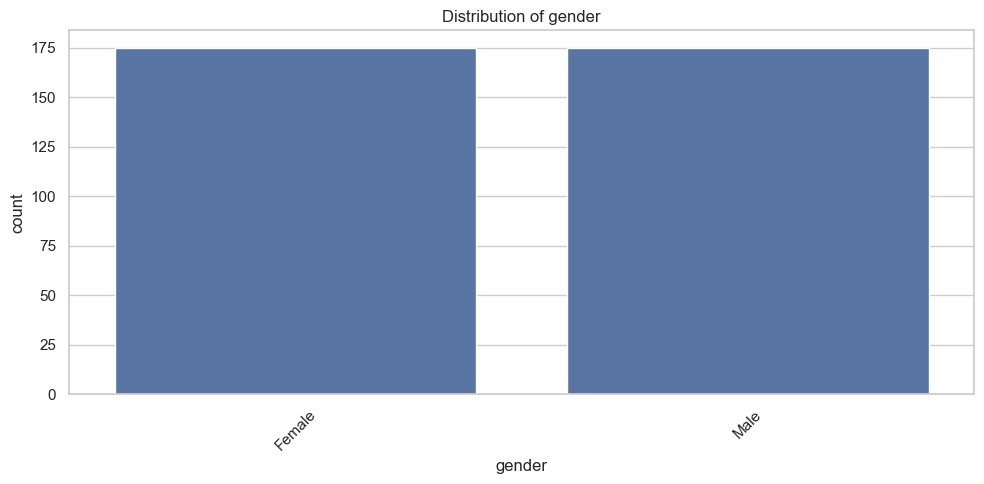

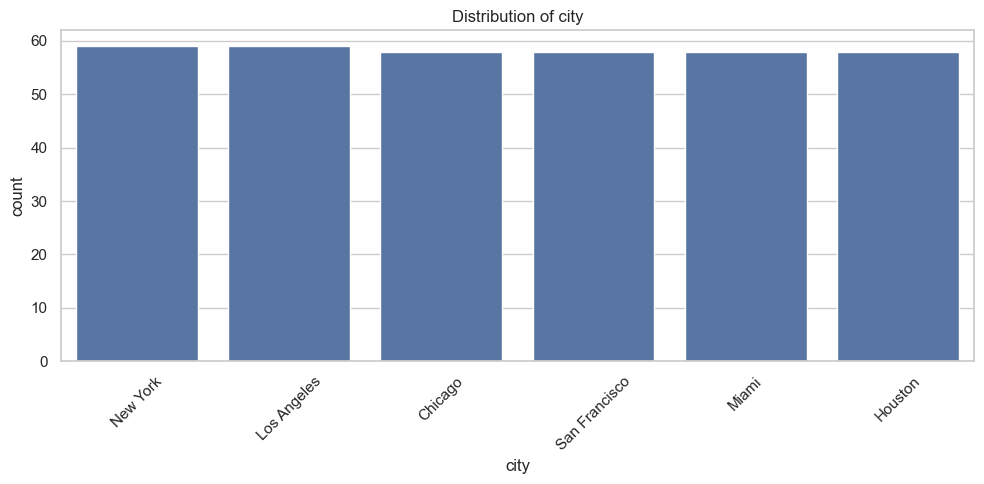

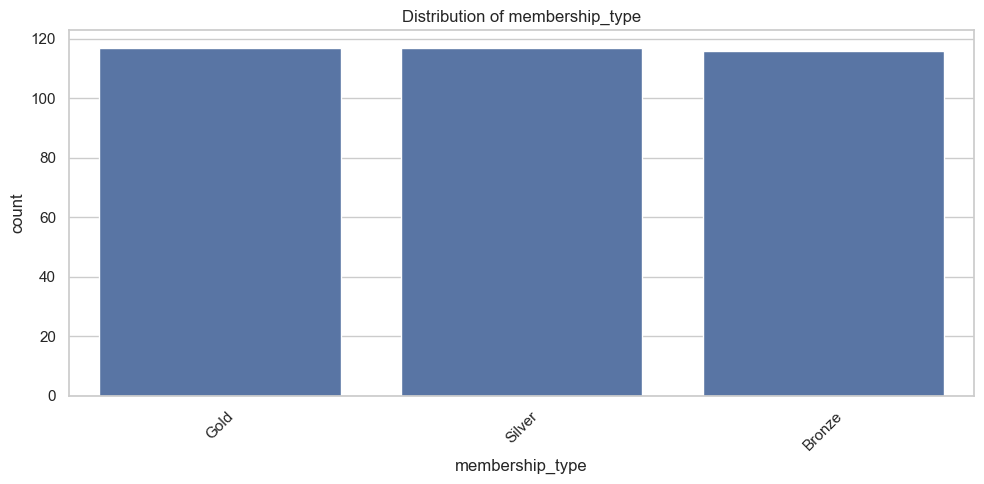

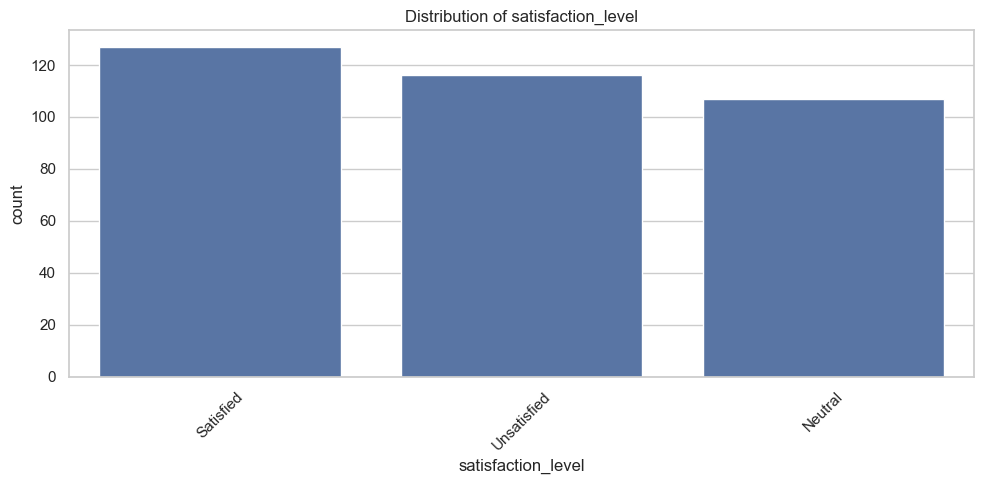

In [46]:
for column in categorical_columns:
    
    if df[column].nunique() <= 15:
        
        plt.figure(figsize=(10, 5))
        
        order = df[column].value_counts().index
        
        sns.countplot(
            data=df,
            x=column,
            order=order
        )
        
        plt.title(f"Distribution of {column}")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [47]:
def find_column(possible_names):
    """
    Find a matching column from possible names.
    """
    for name in possible_names:
        if name in df.columns:
            return name
    
    return None


age_col = find_column([
    "age",
    "customer_age"
])

gender_col = find_column([
    "gender",
    "sex"
])

purchase_col = find_column([
    "purchase_amount",
    "purchase_amount_usd",
    "amount",
    "total_purchase",
    "total_amount",
    "revenue",
    "sales"
])

category_col = find_column([
    "product_category",
    "category",
    "product_category_name"
])

payment_col = find_column([
    "payment_method",
    "payment_type",
    "payment"
])

satisfaction_col = find_column([
    "satisfaction",
    "satisfaction_score",
    "customer_satisfaction",
    "rating",
    "review_rating"
])

frequency_col = find_column([
    "purchase_frequency",
    "purchase_frequency_days",
    "frequency"
])

print("Detected Important Columns")
print("-" * 50)

print("Age:", age_col)
print("Gender:", gender_col)
print("Purchase Amount:", purchase_col)
print("Category:", category_col)
print("Payment Method:", payment_col)
print("Satisfaction:", satisfaction_col)
print("Purchase Frequency:", frequency_col)

Detected Important Columns
--------------------------------------------------
Age: age
Gender: gender
Purchase Amount: None
Category: None
Payment Method: None
Satisfaction: None
Purchase Frequency: None


# Customer Behavior KPI

In [48]:
print("=" * 70)
print("CUSTOMER BEHAVIOR KPIs")
print("=" * 70)

total_records = len(df)

print("Total Records:", total_records)

if purchase_col:
    total_revenue = df[purchase_col].sum()
    average_purchase = df[purchase_col].mean()
    
    print(f"Total Purchase Value: {total_revenue:,.2f}")
    print(f"Average Purchase Value: {average_purchase:,.2f}")

if age_col:
    print(f"Average Customer Age: {df[age_col].mean():.2f}")

if satisfaction_col:
    print(f"Average Satisfaction: {df[satisfaction_col].mean():.2f}")

CUSTOMER BEHAVIOR KPIs
Total Records: 350
Average Customer Age: 33.60


# Gender Distribution

gender
Female    175
Male      175
Name: count, dtype: int64


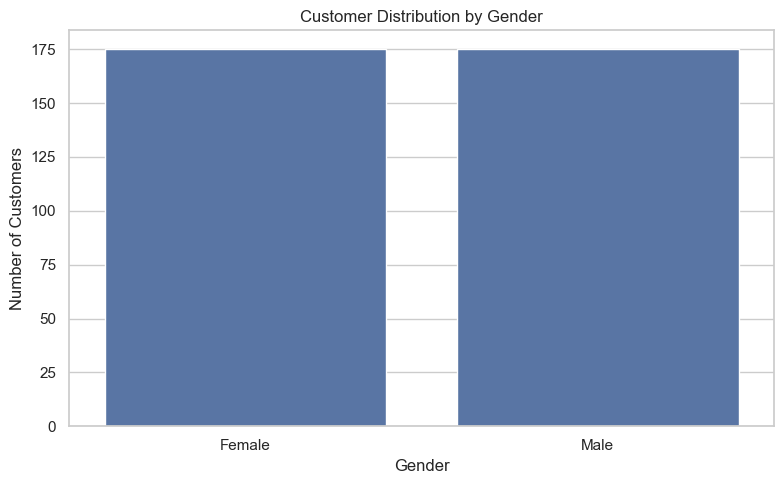

In [49]:
if gender_col:
    
    gender_counts = df[gender_col].value_counts()
    
    print(gender_counts)
    
    plt.figure(figsize=(8, 5))
    
    sns.barplot(
        x=gender_counts.index,
        y=gender_counts.values
    )
    
    plt.title("Customer Distribution by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Number of Customers")
    
    plt.tight_layout()
    plt.show()

In [50]:
if gender_col and purchase_col:
    
    gender_purchase = (
        df.groupby(gender_col)[purchase_col]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
    )
    
    print(gender_purchase)

In [51]:
if gender_col and purchase_col:
    
    gender_revenue = (
        df.groupby(gender_col)[purchase_col]
        .sum()
        .sort_values(ascending=False)
    )
    
    plt.figure(figsize=(8, 5))
    
    sns.barplot(
        x=gender_revenue.index,
        y=gender_revenue.values
    )
    
    plt.title("Purchase Value by Gender")
    plt.xlabel("Gender")
    plt.ylabel("Total Purchase Value")
    
    plt.tight_layout()
    plt.show()

# Age Distribution

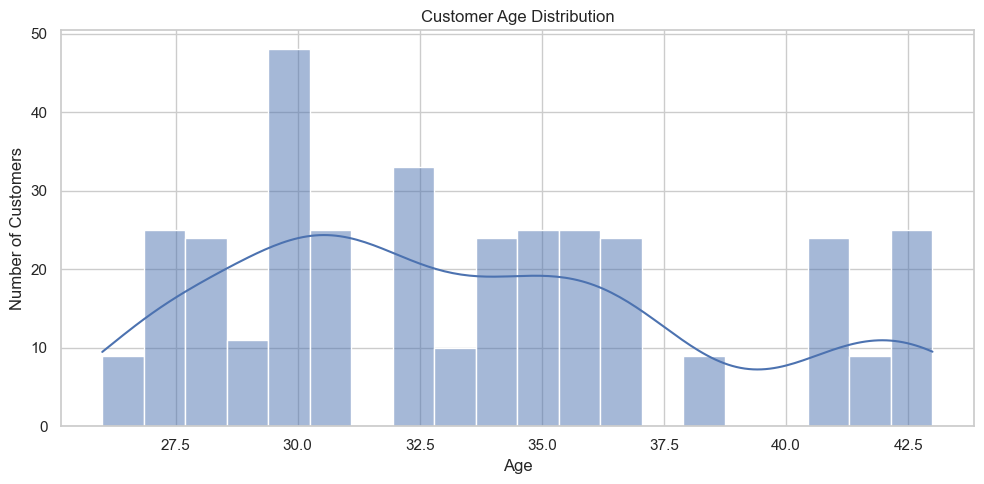

In [52]:
if age_col:
    
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df,
        x=age_col,
        bins=20,
        kde=True
    )
    
    plt.title("Customer Age Distribution")
    plt.xlabel("Age")
    plt.ylabel("Number of Customers")
    
    plt.tight_layout()
    plt.show()

In [53]:
if age_col:
    
    bins = [0, 18, 25, 35, 45, 55, 65, 100]
    
    labels = [
        "Under 18",
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+"
    ]
    
    df["age_group"] = pd.cut(
        df[age_col],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    
    age_group_counts = df["age_group"].value_counts().sort_index()
    
    print(age_group_counts)

age_group
Under 18      0
18-24         0
25-34       234
35-44       116
45-54         0
55-64         0
65+           0
Name: count, dtype: int64


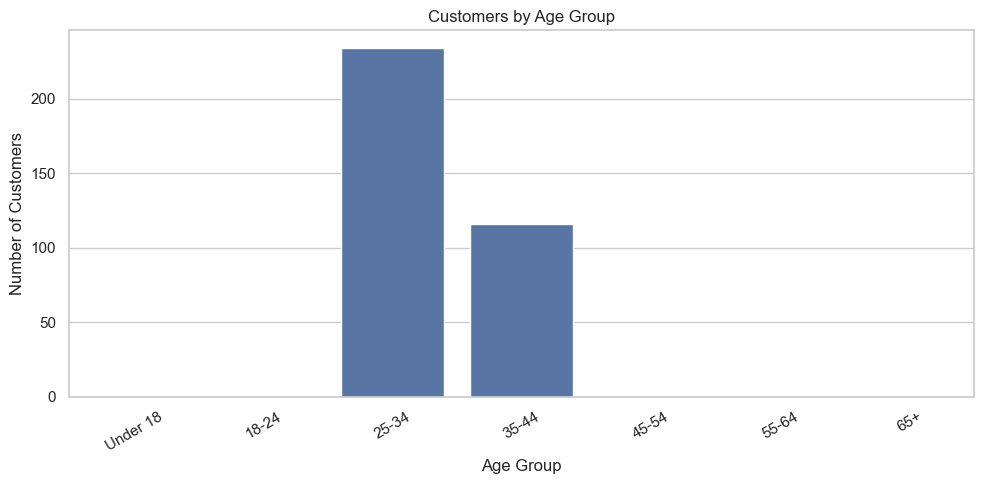

In [54]:
if age_col:
    
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        x=age_group_counts.index,
        y=age_group_counts.values
    )
    
    plt.title("Customers by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Customers")
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [82]:
print(df.columns.tolist())

['customer_id', 'gender', 'age', 'city', 'membership_type', 'total_spend', 'items_purchased', 'average_rating', 'discount_applied', 'days_since_last_purchase', 'satisfaction_level', 'age_group']


# Product Category Analysis

In [ ]:
if category_col:
    
    category_counts = df[category_col].value_counts()
    
    print(category_counts)
    
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        x=category_counts.index,
        y=category_counts.values
    )
    
    plt.title("Customers by Product Category")
    plt.xlabel("Product Category")
    plt.ylabel("Number of Customers")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Purchase Amount Distribution 

In [ ]:
if category_col and purchase_col:
    
    category_revenue = (
        df.groupby(category_col)[purchase_col]
        .agg(["count", "sum", "mean"])
        .sort_values("sum", ascending=False)
    )
    
    category_revenue

In [ ]:
if category_col and purchase_col:
    
    revenue_by_category = (
        df.groupby(category_col)[purchase_col]
        .sum()
        .sort_values(ascending=False)
    )
    
    plt.figure(figsize=(11, 6))
    
    sns.barplot(
        x=revenue_by_category.index,
        y=revenue_by_category.values
    )
    
    plt.title("Total Purchase Value by Product Category")
    plt.xlabel("Product Category")
    plt.ylabel("Total Purchase Value")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Amount by Category

In [ ]:
if payment_col:
    
    payment_counts = df[payment_col].value_counts()
    
    print(payment_counts)
    
    plt.figure(figsize=(9, 5))
    
    sns.barplot(
        x=payment_counts.index,
        y=payment_counts.values
    )
    
    plt.title("Customer Payment Method Distribution")
    plt.xlabel("Payment Method")
    plt.ylabel("Number of Transactions")
    
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
if payment_col and purchase_col:
    
    payment_revenue = (
        df.groupby(payment_col)[purchase_col]
        .sum()
        .sort_values(ascending=False)
    )
    
    print(payment_revenue)

In [ ]:
if satisfaction_col:
    
    print("Satisfaction Statistics")
    print("=" * 50)
    
    print(df[satisfaction_col].describe())
    
    plt.figure(figsize=(9, 5))
    
    sns.histplot(
        data=df,
        x=satisfaction_col,
        kde=True
    )
    
    plt.title("Customer Satisfaction Distribution")
    plt.xlabel("Satisfaction")
    plt.ylabel("Number of Customers")
    
    plt.tight_layout()
    plt.show()

In [ ]:
if satisfaction_col and purchase_col:
    
    plt.figure(figsize=(9, 6))
    
    sns.scatterplot(
        data=df,
        x=satisfaction_col,
        y=purchase_col
    )
    
    plt.title("Purchase Amount vs Customer Satisfaction")
    plt.xlabel("Customer Satisfaction")
    plt.ylabel("Purchase Amount")
    
    plt.tight_layout()
    plt.show()

In [ ]:
if purchase_col:
    
    # Create customer value segments based on quartiles
    df["customer_value_segment"] = pd.qcut(
        df[purchase_col],
        q=4,
        labels=[
            "Low Value",
            "Medium-Low Value",
            "Medium-High Value",
            "High Value"
        ],
        duplicates="drop"
    )
    
    print(df["customer_value_segment"].value_counts())

In [ ]:
if purchase_col:
    
    segment_counts = (
        df["customer_value_segment"]
        .value_counts()
        .sort_index()
    )
    
    plt.figure(figsize=(10, 5))
    
    sns.barplot(
        x=segment_counts.index,
        y=segment_counts.values
    )
    
    plt.title("Customer Value Segmentation")
    plt.xlabel("Customer Segment")
    plt.ylabel("Number of Customers")
    
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

In [ ]:
if purchase_col:
    
    segment_analysis = (
        df.groupby("customer_value_segment", observed=True)[purchase_col]
        .agg(
            Customers="count",
            Total_Value="sum",
            Average_Value="mean"
        )
    )
    
    segment_analysis

In [ ]:
if age_col and purchase_col:
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df,
        x=age_col,
        y=purchase_col
    )
    
    plt.title("Customer Age vs Purchase Amount")
    plt.xlabel("Customer Age")
    plt.ylabel("Purchase Amount")
    
    plt.tight_layout()
    plt.show()

In [ ]:
if purchase_col:
    
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df,
        x=purchase_col,
        bins=30,
        kde=True
    )
    
    plt.title("Purchase Amount Distribution")
    plt.xlabel("Purchase Amount")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

In [ ]:
if purchase_col:
    
    top_customers = (
        df.sort_values(
            by=purchase_col,
            ascending=False
        )
        .head(10)
    )
    
    print("Top 10 Highest-Value Transactions/Customers:")
    
    display(top_customers)

In [ ]:
if purchase_col:
    
    numeric_corr = (
        df[numeric_columns]
        .corr()[purchase_col]
        .sort_values(ascending=False)
    )
    
    print("Correlation with Purchase Amount:")
    print(numeric_corr)

In [ ]:
if age_col and purchase_col:
    
    correlation, p_value = stats.pearsonr(
        df[age_col].dropna(),
        df.loc[df[age_col].notna(), purchase_col]
    )
    
    print("Pearson Correlation Analysis")
    print("=" * 50)
    print(f"Correlation: {correlation:.4f}")
    print(f"P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print("Result: Statistically significant relationship.")
    else:
        print("Result: No statistically significant relationship detected.")

# KPI Business insights

In [ ]:
insights = []

# Dataset insight
insights.append(
    f"The dataset contains {len(df):,} records and {len(df.columns):,} columns."
)

# Purchase insight
if purchase_col:
    
    total_revenue = df[purchase_col].sum()
    average_purchase = df[purchase_col].mean()
    
    insights.append(
        f"Total purchase value is {total_revenue:,.2f}, "
        f"with an average purchase value of {average_purchase:,.2f}."
    )

# Gender insight
if gender_col and purchase_col:
    
    gender_avg = (
        df.groupby(gender_col)[purchase_col]
        .mean()
        .sort_values(ascending=False)
    )
    
    highest_gender = gender_avg.index[0]
    
    insights.append(
        f"{highest_gender} has the highest average purchase value "
        f"among the available gender categories."
    )

# Category insight
if category_col and purchase_col:
    
    category_total = (
        df.groupby(category_col)[purchase_col]
        .sum()
        .sort_values(ascending=False)
    )
    
    top_category = category_total.index[0]
    
    insights.append(
        f"{top_category} generates the highest total purchase value "
        f"among the product categories."
    )

# Payment insight
if payment_col:
    
    top_payment = df[payment_col].value_counts().index[0]
    
    insights.append(
        f"{top_payment} is the most frequently used payment method."
    )

# Satisfaction insight
if satisfaction_col:
    
    avg_satisfaction = df[satisfaction_col].mean()
    
    insights.append(
        f"The average customer satisfaction score is "
        f"{avg_satisfaction:.2f}."
    )

print("=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

# Data Summary

In [71]:
summary_data = {
    "Metric": [],
    "Value": []
}

summary_data["Metric"].append("Total Records")
summary_data["Value"].append(len(df))

if purchase_col:
    summary_data["Metric"].extend([
        "Total Purchase Value",
        "Average Purchase Value",
        "Maximum Purchase Value",
        "Minimum Purchase Value"
    ])
    
    summary_data["Value"].extend([
        round(df[purchase_col].sum(), 2),
        round(df[purchase_col].mean(), 2),
        round(df[purchase_col].max(), 2),
        round(df[purchase_col].min(), 2)
    ])

if age_col:
    summary_data["Metric"].append("Average Customer Age")
    summary_data["Value"].append(round(df[age_col].mean(), 2))

if satisfaction_col:
    summary_data["Metric"].append("Average Satisfaction")
    summary_data["Value"].append(round(df[satisfaction_col].mean(), 2))

summary_df = pd.DataFrame(summary_data)

summary_df

,Metric,Value
0,Total Records,350.0
1,Average Customer Age,33.6


In [72]:
print("=" * 70)
print("DATA QUALITY TESTING")
print("=" * 70)

# Test 1: Dataset should not be empty
assert len(df) > 0, "Dataset is empty!"

# Test 2: Dataset should have columns
assert len(df.columns) > 0, "No columns found!"

# Test 3: Duplicate check
assert df.duplicated().sum() == 0, "Duplicate records still exist!"

# Test 4: Missing values
remaining_missing = df.isnull().sum().sum()

print("Test 1 - Dataset not empty: PASSED")
print("Test 2 - Columns available: PASSED")
print("Test 3 - No duplicate records:", "PASSED" if df.duplicated().sum() == 0 else "FAILED")
print(
    "Test 4 - Missing values:",
    "PASSED" if remaining_missing == 0 else f"{remaining_missing} values remaining"
)

DATA QUALITY TESTING
Test 1 - Dataset not empty: PASSED
Test 2 - Columns available: PASSED
Test 3 - No duplicate records: PASSED
Test 4 - Missing values: PASSED


In [73]:
print("=" * 70)
print("NUMERICAL VALIDATION")
print("=" * 70)

for column in numeric_columns:
    
    if column in df.columns:
        
        negative_values = (df[column] < 0).sum()
        
        print(
            f"{column}: "
            f"Negative Values = {negative_values}"
        )

NUMERICAL VALIDATION
customer_id: Negative Values = 0
age: Negative Values = 0
total_spend: Negative Values = 0
items_purchased: Negative Values = 0
average_rating: Negative Values = 0
days_since_last_purchase: Negative Values = 0


In [74]:
# Create output directory
output_folder = "customer_behavior_analysis_output"

os.makedirs(
    output_folder,
    exist_ok=True
)

print("Output folder created:")
print(os.path.abspath(output_folder))

Output folder created:
C:\Users\amans\customer_behavior_analysis_output


In [75]:
# Create output directory
output_folder = "customer_behavior_analysis_output"

os.makedirs(
    output_folder,
    exist_ok=True
)

print("Output folder created:")
print(os.path.abspath(output_folder))

Output folder created:
C:\Users\amans\customer_behavior_analysis_output


In [76]:
report_file = os.path.join(
    output_folder,
    "Customer_Behavior_Analysis_Report.txt"
)

with open(
    report_file,
    "w",
    encoding="utf-8"
) as report:
    
    report.write("=" * 80 + "\n")
    report.write("              CUSTOMER BEHAVIOR ANALYSIS REPORT\n")
    report.write("=" * 80 + "\n\n")
    
    report.write("1. PROJECT OVERVIEW\n")
    report.write("-" * 80 + "\n")
    report.write(
        "This project analyzes e-commerce customer behavior using "
        "data cleaning, exploratory data analysis, visualization, "
        "customer segmentation and statistical analysis.\n\n"
    )
    
    report.write("2. DATASET INFORMATION\n")
    report.write("-" * 80 + "\n")
    report.write(f"Total Records: {len(df):,}\n")
    report.write(f"Total Columns: {len(df.columns):,}\n")
    report.write(f"Duplicate Records: {df.duplicated().sum()}\n")
    report.write(
        f"Missing Values: {df.isnull().sum().sum()}\n\n"
    )
    
    report.write("3. KEY PERFORMANCE INDICATORS\n")
    report.write("-" * 80 + "\n")
    
    for _, row in summary_df.iterrows():
        report.write(
            f"{row['Metric']}: {row['Value']}\n"
        )
    
    report.write("\n4. KEY BUSINESS INSIGHTS\n")
    report.write("-" * 80 + "\n")
    
    for i, insight in enumerate(insights, 1):
        report.write(f"{i}. {insight}\n")
    
    report.write("\n5. DATA SCIENCE WORKFLOW\n")
    report.write("-" * 80 + "\n")
    report.write(
        "Data Loading -> Data Cleaning -> EDA -> Visualization -> "
        "Customer Segmentation -> Statistical Analysis -> "
        "Business Insights -> Report Generation\n"
    )

print("Complete report generated successfully!")
print(report_file)

Complete report generated successfully!
customer_behavior_analysis_output\Customer_Behavior_Analysis_Report.txt
